In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
DATA_PATH = Path("../data/raw/WineQT.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
TARGET = "quality"
ID_COL = "Id"

y = df[TARGET]
X = df.drop(columns=[TARGET, ID_COL])

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [5]:
quality_distribution_split = pd.concat(
    [
        y_train.value_counts(normalize=True).sort_index().rename("train_proportion"),
        y_test.value_counts(normalize=True).sort_index().rename("test_proportion"),
    ],
    axis=1,
)

quality_distribution_split

,train_proportion,test_proportion
quality,,
3,0.005470,0.004367
4,0.028446,0.030568
5,0.422319,0.423581
6,0.404814,0.401747
7,0.124726,0.126638
8,0.014223,0.013100


The same stratified holdout split as in previous stages was reused.
This is the first and only final evaluation on `X_test`.
No model parameters will be changed after seeing the test results.

Шаг 6.5 — define frozen final candidate

In [6]:
final_model = ExtraTreesRegressor(
    max_depth=None,
    max_features=1.0,
    min_samples_leaf=2,
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
)

final_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

In [7]:
final_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

In [8]:
y_test_pred = final_model.predict(X_test)

Шаг 6.8 — final test metrics

In [9]:
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

final_test_metrics = pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "R2"],
        "test_value": [test_mae, test_rmse, test_r2],
    }
)

final_test_metrics

,metric,test_value
0,MAE,0.413733
1,RMSE,0.584378
2,R2,0.470696


Шаг 6.9 — compare with Stage 5 CV

In [10]:
stage5_cv_metrics = {
    "MAE": 0.4414,
    "RMSE": 0.5854,
    "R2": 0.4688,
}

comparison_with_cv = final_test_metrics.copy()
comparison_with_cv["stage5_cv_mean"] = comparison_with_cv["metric"].map(stage5_cv_metrics)
comparison_with_cv["test_minus_cv"] = (
    comparison_with_cv["test_value"] - comparison_with_cv["stage5_cv_mean"]
)

comparison_with_cv

,metric,test_value,stage5_cv_mean,test_minus_cv
0,MAE,0.413733,0.4414,-0.027667
1,RMSE,0.584378,0.5854,-0.001022
2,R2,0.470696,0.4688,0.001896


Шаг 6.10 — prediction diagnostics без изменения модели

In [13]:
prediction_diagnostics = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_test_pred,
    "error": y_test_pred - y_test,
    "abs_error": np.abs(y_test_pred - y_test),
})

prediction_diagnostics.head()

,y_true,y_pred,error,abs_error
96,6,6.272600,0.272600,0.272600
442,5,4.921333,-0.078667,0.078667
872,5,5.198667,0.198667,0.198667
764,5,5.199833,0.199833,0.199833
570,5,5.422167,0.422167,0.422167


In [14]:
prediction_diagnostics["abs_error"].describe()

count    229.000000
mean       0.413733
std        0.413606
min        0.002333
25%        0.111000
50%        0.303167
75%        0.590667
max        2.209000
Name: abs_error, dtype: float64

In [15]:
error_by_quality = (
    prediction_diagnostics
    .groupby("y_true")
    .agg(
        count=("abs_error", "size"),
        mae=("abs_error", "mean"),
        mean_error=("error", "mean"),
    )
)

error_by_quality

,count,mae,mean_error
y_true,,,
3,1,2.209000,2.209000
4,7,1.338571,1.338571
5,97,0.283065,0.271443
6,92,0.356576,-0.167024
7,29,0.621599,-0.621599
8,3,1.625722,-1.625722


Шаг 6.11 — optional plot

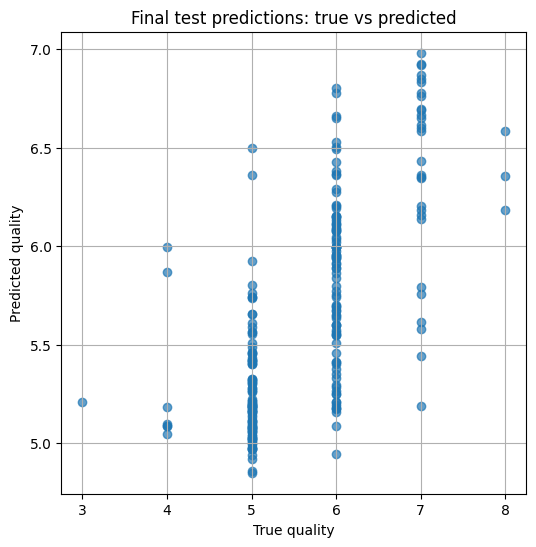

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.xlabel("True quality")
plt.ylabel("Predicted quality")
plt.title("Final test predictions: true vs predicted")
plt.grid(True)
plt.show()

## Final evaluation conclusions

### Setup

- Task type: regression.
- Target: `quality`.
- Excluded column: `Id`.
- Final frozen candidate: tuned `ExtraTreesRegressor`.
- Final model parameters:
  - `max_depth=None`;
  - `max_features=1.0`;
  - `min_samples_leaf=2`;
  - `n_estimators=500`;
  - `random_state=42`;
  - `n_jobs=-1`.
- The same train/test split as previous stages was used:
  - `test_size=0.2`;
  - `random_state=42`;
  - `stratify=y`.
- The model was fitted on `X_train` / `y_train` only.
- This was the first and only evaluation on `X_test` / `y_test`.

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [26]:
y_test_pred_rounded = np.rint(y_test_pred).astype(int)

y_min = y.min()
y_max = y.max()

y_test_pred_rounded = np.clip(
    y_test_pred_rounded,
    y_min,
    y_max,
)

In [27]:
rounded_prediction_distribution = pd.Series(
    y_test_pred_rounded,
    name="predicted_quality_rounded"
).value_counts().sort_index()

rounded_prediction_distribution

predicted_quality_rounded
5    110
6     97
7     22
Name: count, dtype: int64

In [28]:
true_test_distribution = y_test.value_counts().sort_index()

rounded_distribution_comparison = pd.concat(
    [
        true_test_distribution.rename("true_count"),
        rounded_prediction_distribution.rename("predicted_rounded_count"),
    ],
    axis=1,
).fillna(0).astype(int)

rounded_distribution_comparison

,true_count,predicted_rounded_count
3,1,0
4,7,0
5,97,110
6,92,97
7,29,22
8,3,0


4. Precision и другие classification-style метрики

Macro precision macro считает precision по каждому классу отдельно, а потом усредняет. Он чувствителен к редким классам.

In [29]:
rounded_precision_macro = precision_score(
    y_test,
    y_test_pred_rounded,
    average="macro",
    zero_division=0,
)

rounded_precision_macro

0.3480474851608872

Weighted precision weighted учитывает поддержку классов. Из-за доминирования 5 и 6 может выглядеть лучше, чем macro.

In [30]:
rounded_precision_weighted = precision_score(
    y_test,
    y_test_pred_rounded,
    average="weighted",
    zero_division=0,
)

rounded_precision_weighted

0.6674649979741594

Полный набор rounded diagnostics

In [31]:
rounded_classification_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred_rounded),
    "precision_macro": precision_score(
        y_test,
        y_test_pred_rounded,
        average="macro",
        zero_division=0,
    ),
    "precision_weighted": precision_score(
        y_test,
        y_test_pred_rounded,
        average="weighted",
        zero_division=0,
    ),
    "recall_macro": recall_score(
        y_test,
        y_test_pred_rounded,
        average="macro",
        zero_division=0,
    ),
    "recall_weighted": recall_score(
        y_test,
        y_test_pred_rounded,
        average="weighted",
        zero_division=0,
    ),
    "f1_macro": f1_score(
        y_test,
        y_test_pred_rounded,
        average="macro",
        zero_division=0,
    ),
    "f1_weighted": f1_score(
        y_test,
        y_test_pred_rounded,
        average="weighted",
        zero_division=0,
    ),
}

rounded_classification_metrics = pd.Series(
    rounded_classification_metrics,
    name="value",
)

rounded_classification_metrics

accuracy              0.703057
precision_macro       0.348047
precision_weighted    0.667465
recall_macro          0.343136
recall_weighted       0.703057
f1_macro              0.343112
f1_weighted           0.682324
Name: value, dtype: float64

5. Classification report

In [32]:
rounded_classification_report = classification_report(
    y_test,
    y_test_pred_rounded,
    zero_division=0,
)

print(rounded_classification_report)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.74      0.84      0.78        97
           6       0.67      0.71      0.69        92
           7       0.68      0.52      0.59        29
           8       0.00      0.00      0.00         3

    accuracy                           0.70       229
   macro avg       0.35      0.34      0.34       229
weighted avg       0.67      0.70      0.68       229



6. Confusion matrix

In [33]:
quality_labels = sorted(y.unique())

rounded_confusion_matrix = pd.DataFrame(
    confusion_matrix(
        y_test,
        y_test_pred_rounded,
        labels=quality_labels,
    ),
    index=[f"true_{label}" for label in quality_labels],
    columns=[f"pred_{label}" for label in quality_labels],
)

rounded_confusion_matrix

,pred_3,pred_4,pred_5,pred_6,pred_7,pred_8
true_3,0,0,1,0,0,0
true_4,0,0,5,2,0,0
true_5,0,0,81,16,0,0
true_6,0,0,21,65,6,0
true_7,0,0,2,12,15,0
true_8,0,0,0,2,1,0


### Auxiliary rounded prediction diagnostics

Although the main task framing is regression, rounded predictions were also inspected as an auxiliary diagnostic.

The continuous test predictions were rounded to the nearest integer quality score and clipped to the observed target range.

These classification-style metrics were not used for model selection or hyperparameter tuning.

## Final evaluation conclusions

### Setup

- Task type: regression.
- Target: `quality`.
- Excluded column: `Id`.
- Final frozen candidate: tuned `ExtraTreesRegressor`.
- Final model parameters:
  - `max_depth=None`;
  - `max_features=1.0`;
  - `min_samples_leaf=2`;
  - `n_estimators=500`;
  - `random_state=42`;
  - `n_jobs=-1`.
- The same train/test split as previous stages was used:
  - `test_size=0.2`;
  - `random_state=42`;
  - `stratify=y`.
- The model was fitted on `X_train` / `y_train` only.
- This was the first and only evaluation on `X_test` / `y_test`.
- No model parameters were changed after seeing the test results.

### Final test metrics

- MAE ≈ 0.4137
- RMSE ≈ 0.5844
- R² ≈ 0.4707

### Comparison with Stage 5 CV

Stage 5 CV metrics:

- MAE ≈ 0.4414;
- RMSE ≈ 0.5854;
- R² ≈ 0.4688.

Final test metrics were close to CV expectations:

- test MAE was slightly better than CV MAE by approximately 0.0277;
- test RMSE was almost identical to CV RMSE;
- test R² was almost identical to CV R².

This suggests no strong signs of overfitting or instability. The final model generalized to the held-out test set approximately as expected from cross-validation.

### Error analysis

Errors are much smaller for common quality values 5 and 6:

- quality 5: MAE ≈ 0.2831;
- quality 6: MAE ≈ 0.3566.

Errors are larger for rare or extreme quality values:

- quality 3: MAE ≈ 2.2090, but only 1 test observation;
- quality 4: MAE ≈ 1.3386, with 7 test observations;
- quality 8: MAE ≈ 1.6257, with 3 test observations.

The model tends to compress predictions toward the common middle quality range:

- low true quality values 3 and 4 are overestimated;
- high true quality values 7 and 8 are underestimated.

This is expected for a regression model trained on an imbalanced ordinal target where most observations have quality 5 or 6.

### Auxiliary rounded prediction diagnostics

Although the main task framing is regression, rounded predictions were inspected as an auxiliary diagnostic.

Continuous predictions were rounded to the nearest integer quality score and clipped to the observed target range.

Rounded classification-style metrics:

- accuracy ≈ 0.7031;
- macro precision ≈ 0.3480;
- weighted precision ≈ 0.6675;
- macro recall ≈ 0.3431;
- weighted recall ≈ 0.7031;
- macro F1 ≈ 0.3431;
- weighted F1 ≈ 0.6823.

These metrics were not used for model selection or hyperparameter tuning.

The rounded predictions were concentrated around classes 5, 6, and 7. The model did not predict classes 3, 4, or 8 after rounding. This explains why weighted metrics look acceptable while macro metrics are weak.

This confirms that the regression model is useful for approximate quality scoring, but it is not a strong exact-class predictor across all quality levels.

### Honest model quality

The final model is useful as an educational regression model for this dataset:

- it clearly improves over the simple linear baseline;
- it generalizes consistently from CV to held-out test;
- MAE around 0.41 means the model is typically less than half a quality point away from the true score.

However, the model has important limitations:

- quality prediction remains difficult because the target is ordinal and imbalanced;
- extreme quality scores are rare and poorly predicted;
- predictions are compressed toward common classes 5 and 6;
- R² around 0.47 means a substantial part of variation remains unexplained.

### Limitations of regression framing

- `quality` is ordinal, not truly continuous.
- The model predicts continuous values even though observed quality scores are discrete integers.
- MAE and RMSE are useful, but they do not fully capture exact ordinal classification quality.
- Rare quality levels are hard to evaluate reliably because there are few examples.
- Multiclass and binary formulations may be tested later as alternative task framings.

### Leakage control

- `Id` was excluded from the feature matrix.
- The final candidate was frozen before test evaluation.
- The model was fitted only on `X_train`.
- `X_test` was evaluated exactly once.
- No hyperparameter tuning was performed after seeing test results.
- No model parameters were changed after test evaluation.
- No outliers were removed.
- No target transformation was applied.
- Predictions were not rounded for primary metric calculation.
- Rounded metrics were used only as auxiliary diagnostics.
- No multiclass or binary framing was used.
- The final model was not saved yet.